In [1]:
import os
import glob
import pickle
import re
from collections import defaultdict
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Root folder — one sub-directory per subject, e.g. data/NF/002GNV/
DATA_ROOT = "../../../Data/"

FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

In [3]:
import sys
sys.path.append("../utils")
from metrics import load_subject, compute_all_metrics

In [4]:
def discover_subjects(data_root):
    return sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    )

In [5]:
subject_ids = discover_subjects(DATA_ROOT)
print(f"Subjects found: {subject_ids}\n")

all_data = {}
for sid in subject_ids:
    sessions, yeo_labels = load_subject(DATA_ROOT, sid)
    all_data[sid] = {"sessions": sessions, "yeo_labels": yeo_labels}

compute_all_metrics(all_data)

Subjects found: ['003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']

  003GNV: 15 session file(s)
  004GNV: 15 session file(s)
  005GNV: 15 session file(s)
  008GNV: 15 session file(s)
  012GNV: 15 session file(s)
  013GNV: 15 session file(s)
  016GNV: 15 session file(s)
  020GNV: 15 session file(s)
  021GNV: 15 session file(s)
  023GNV: 15 session file(s)
  025GNV: 15 session file(s)
  026GNV: 15 session file(s)
  034GNV: 15 session file(s)
  037GNV: 15 session file(s)
  041GNV: 15 session file(s)
  043GNV: 15 session file(s)
  048GNV: 15 session file(s)
  049GNV: 15 session file(s)
  054GNV: 15 session file(s)
  056GNV: 15 session file(s)


In [6]:
sid = list(all_data.keys())[0]
session_id = list(all_data[sid]["sessions"].keys())[0]
run_key = list(all_data[sid]["sessions"][session_id].keys())[0]

run_data = all_data[sid]["sessions"][session_id][run_key]
print(run_data["condition"])
print(run_data["segregation"])
print(run_data["integration"])
print(run_data["normalized_segregation"])

Feedback
[0.6894215  0.64889916 0.66798832 0.61642388 0.53397318 0.66280482
 0.62786584]
[0.47299215 0.54825073 0.49581644 0.52853076 0.50278319 0.54135409
 0.5149008 ]
[0.18618962 0.08407337 0.14793881 0.07676559 0.0300842  0.10085938
 0.09885224]


In [7]:
rows = []

for sid, subj in all_data.items():
    for session_id, runs in subj["sessions"].items():
        session_num = int(str(session_id).replace("V", ""))

        for run_key, rd in runs.items():
            seg = rd["segregation"]
            intg = rd["integration"]
            normseg = rd["normalized_segregation"]
            condition = rd["condition"]

            fc = rd["FC"].copy()
            np.fill_diagonal(fc, np.nan)
            mean_fc = float(np.nanmean(fc))

            for net_id in range(1, 8):
                rows.append({
                    "subject": sid,
                    "session": session_id,
                    "session_num": session_num,
                    "run": run_key,
                    "condition": condition,
                    "network": net_id,
                    "segregation": float(seg[net_id-1]),
                    "integration": float(intg[net_id-1]),
                    "normalized_segregation": float(normseg[net_id-1]),
                    "mean_fc": mean_fc,
                })

df_long = pd.DataFrame(rows)

In [22]:
df_long["normalized_segregation"] = (df_long["segregation"] - df_long["integration"])/df_long["segregation"]

In [8]:
def make_centered_7_axes(figsize=(20, 8), dpi=300):
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 12, wspace=0.5, hspace=0.45)
    axes = [
        fig.add_subplot(gs[0, 0:3]),
        fig.add_subplot(gs[0, 3:6]),
        fig.add_subplot(gs[0, 6:9]),
        fig.add_subplot(gs[0, 9:12]),
        fig.add_subplot(gs[1, 1:4]),
        fig.add_subplot(gs[1, 4:7]),
        fig.add_subplot(gs[1, 7:10]),
    ]
    return fig, axes

In [9]:
NETWORK_COLORS = [
    '#4C78A8',
    '#F58518',
    '#54A24B',
    '#E45756',
    '#72B7B2',
    '#B279A2',
    '#FF9DA6',
]


In [10]:
def stars_from_p(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

In [23]:
mean_fc_per_run = []
for sid, subj in all_data.items():
    for sess_id, runs in subj["sessions"].items():
        for run_key, rd in runs.items():
            fc = rd["FC"]
            np.fill_diagonal(fc := fc.copy(), np.nan)
            mean_fc_per_run.append({
                "subject": sid, "session": sess_id,
                "run": run_key, "mean_fc": np.nanmean(fc)
            })

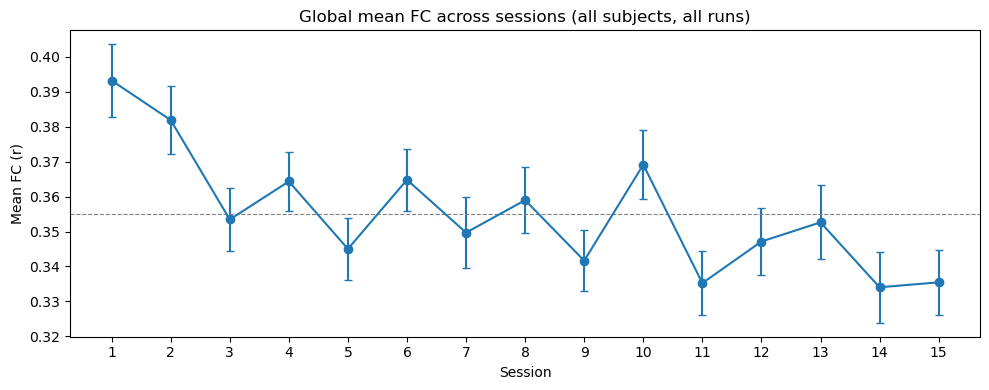

In [12]:
df_mfc = pd.DataFrame(mean_fc_per_run)
df_mfc["session_num"] = df_mfc["session"].str.replace("V", "").astype(int)

# group mean + SEM per session
sess_stats = df_mfc.groupby("session_num")["mean_fc"].agg(["mean", "sem"]).reset_index()

plt.figure(figsize=(10, 4))
plt.errorbar(sess_stats["session_num"], sess_stats["mean"], yerr=sess_stats["sem"],
             fmt="o-", capsize=3)
plt.xlabel("Session")
plt.ylabel("Mean FC (r)")
plt.title("Global mean FC across sessions (all subjects, all runs)")
plt.xticks(sess_stats["session_num"])
plt.axhline(sess_stats["mean"].mean(), color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()


In [24]:
import warnings

def plot_trend_per_network(
    df_long,
    yeo_names,
    metric='segregation',
    control_mean_fc=False,
    control_condition=False,
    condition_filter=None,
    figsize=(20, 8),
    dpi=300,
    save_path=None,
):
    metric_labels = {
        'segregation': 'Segregation',
        'integration': 'Integration',
        'normalized_segregation': 'Normalised Segregation',
    }

    work_df = df_long.copy()
    if condition_filter is not None:
        work_df = work_df[work_df['condition'] == condition_filter].copy()
    cond_str = f" [{condition_filter}]" if condition_filter else ""

    all_sessions = sorted(
        work_df['session'].dropna().unique(),
        key=lambda s: int(str(s).replace('V', ''))
    )
    sess_to_x = {s: i for i, s in enumerate(all_sessions)}

    parts = [f"{metric} ~ session_num"]
    if control_mean_fc:
        parts.append("mean_fc")
    if control_condition:
        parts.append("C(condition, Treatment('Feedback'))")
    formula = " + ".join(parts)

    fig, axes_list = make_centered_7_axes(figsize=figsize, dpi=dpi)
    fig.suptitle(
        f"{metric_labels.get(metric, metric)} per network {cond_str}",
        fontsize=14, fontweight='bold', y=0.98
    )

    stat_rows = []

    for net_i, ax in enumerate(axes_list):
        net_id = net_i + 1
        net_df = work_df[work_df['network'] == net_id].copy()

        if net_df.empty:
            ax.set_title(yeo_names[net_i])
            ax.axis('off')
            continue

        sess_stats = (
            net_df.groupby('session')[metric]
            .agg(mean='mean', sem=lambda x: x.sem())
            .reindex(all_sessions)
            .reset_index()
        )
        sess_stats['x'] = sess_stats['session'].map(sess_to_x)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            lme = smf.mixedlm(formula, data=net_df, groups=net_df["subject"]).fit(
                reml=True, method="lbfgs"
            )

        beta = lme.params["session_num"]
        p    = lme.pvalues["session_num"]

        row = {"network": net_id, "beta_session": beta, "p_session": p}
        if control_condition:
            for cond in ["Transfer", "NoFeedback"]:
                key = f"C(condition, Treatment('Feedback'))[T.{cond}]"
                if key in lme.params:
                    row[f"beta_{cond}"] = lme.params[key]
                    row[f"p_{cond}"]    = lme.pvalues[key]
        stat_rows.append(row)

        x_num = np.linspace(net_df['session_num'].min(), net_df['session_num'].max(), 200)

        y_pred = lme.params['Intercept'] + lme.params['session_num'] * x_num
        if control_mean_fc:
            y_pred += lme.params['mean_fc'] * net_df['mean_fc'].mean()

        x_num_min, x_num_max = net_df['session_num'].min(), net_df['session_num'].max()
        x_axis = (x_num - x_num_min) / (x_num_max - x_num_min) * (len(all_sessions) - 1)

        ax.errorbar(
            sess_stats['x'], sess_stats['mean'], yerr=sess_stats['sem'],
            fmt='o', color=NETWORK_COLORS[net_i],
            markersize=4, linewidth=0.8, elinewidth=0.8, capsize=2,
            label='Session mean ± SEM', zorder=2,
        )

        label_parts = []
        if control_mean_fc:
            label_parts.append("mean_fc held constant")
        if control_condition:
            label_parts.append("condition=Feedback")
        trend_label = f"LME trend ({', '.join(label_parts)})" if label_parts else "LME trend"
        ax.plot(x_axis, y_pred, color='black', linestyle='--', linewidth=1.4,
                label=trend_label, zorder=3)

        ax.set_xticks(range(len(all_sessions)))
        ax.set_xticklabels(all_sessions, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel(metric_labels.get(metric, metric), fontsize=8)
        ax.set_title(yeo_names[net_i], fontsize=10, pad=10)
        ax.spines[['top', 'right']].set_visible(False)

        if metric == 'normalized_segregation':
            ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')

        if net_i == 0:
            ax.legend(fontsize=6, frameon=False)

        stars = stars_from_p(p)
        ax.text(
            0.98, 0.96,
            f"β={beta:.4f}\n({stars})",
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.8),
        )

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()
    return fig, pd.DataFrame(stat_rows)

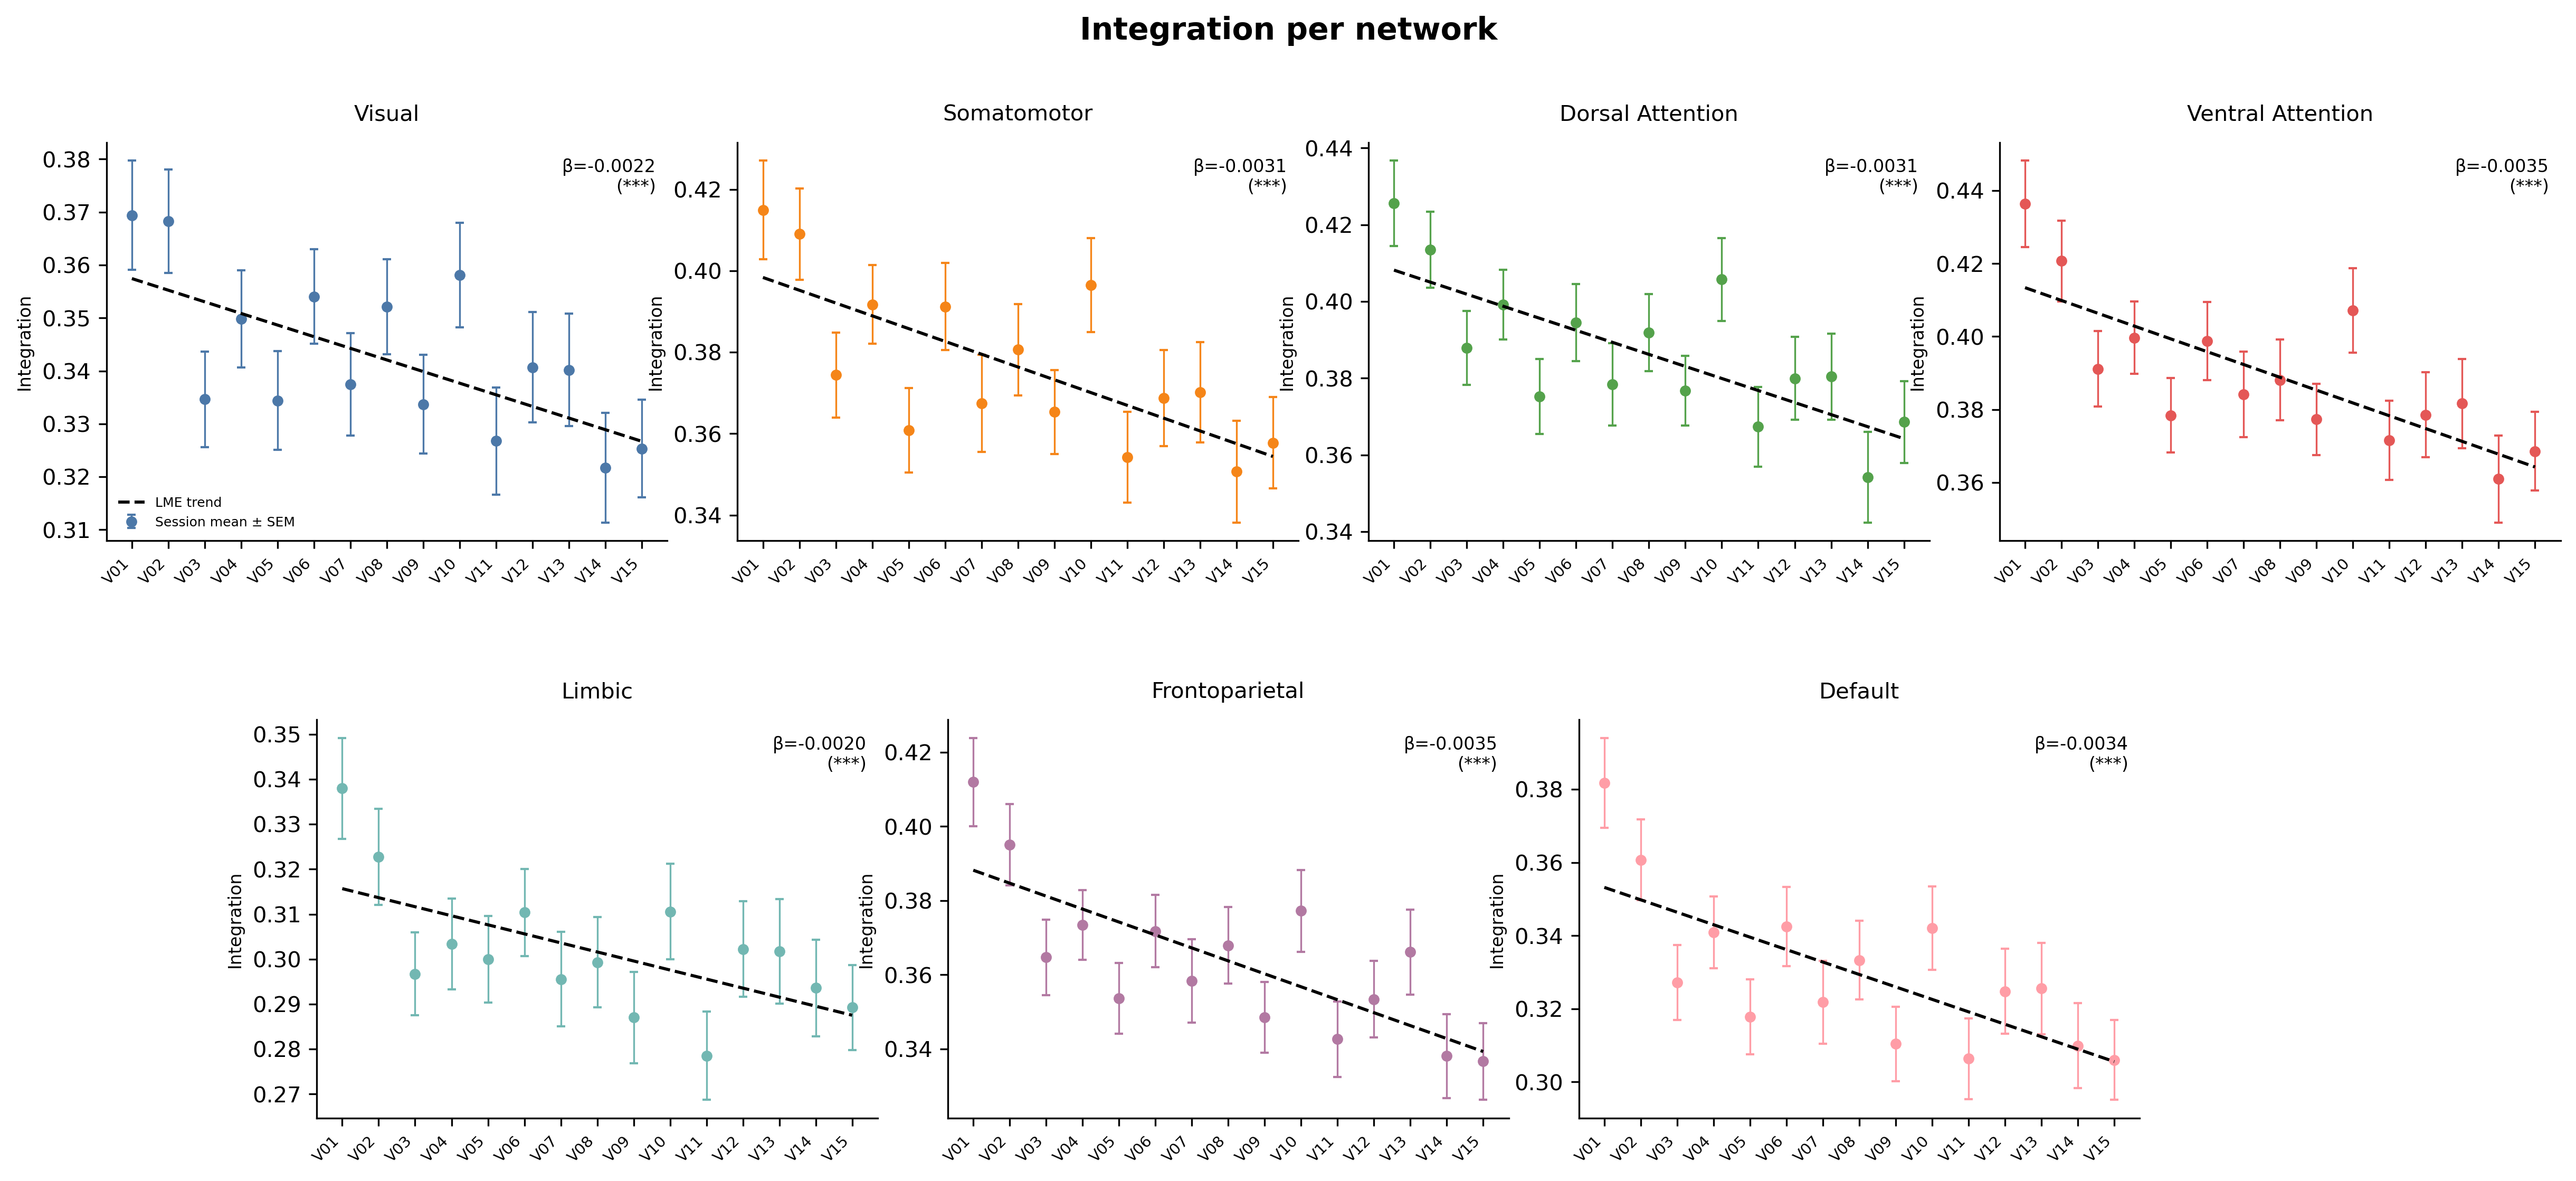

,network,beta_session,p_session
0,1,-0.002195,7.805869e-08
1,2,-0.003139,1.246467e-12
2,3,-0.003138,1.367639e-13
3,4,-0.003512,2.190980e-16
4,5,-0.002010,6.041474e-07
5,6,-0.003490,2.930934e-17
6,7,-0.003403,8.001474e-15


In [14]:
fig, stats_int = plot_trend_per_network(
    df_long=df_long,
    yeo_names=YEO_NAMES,
    metric="integration",
    control_mean_fc=False,
    control_condition=False,
    figsize=(20, 8),
    dpi=300,
)
stats_int

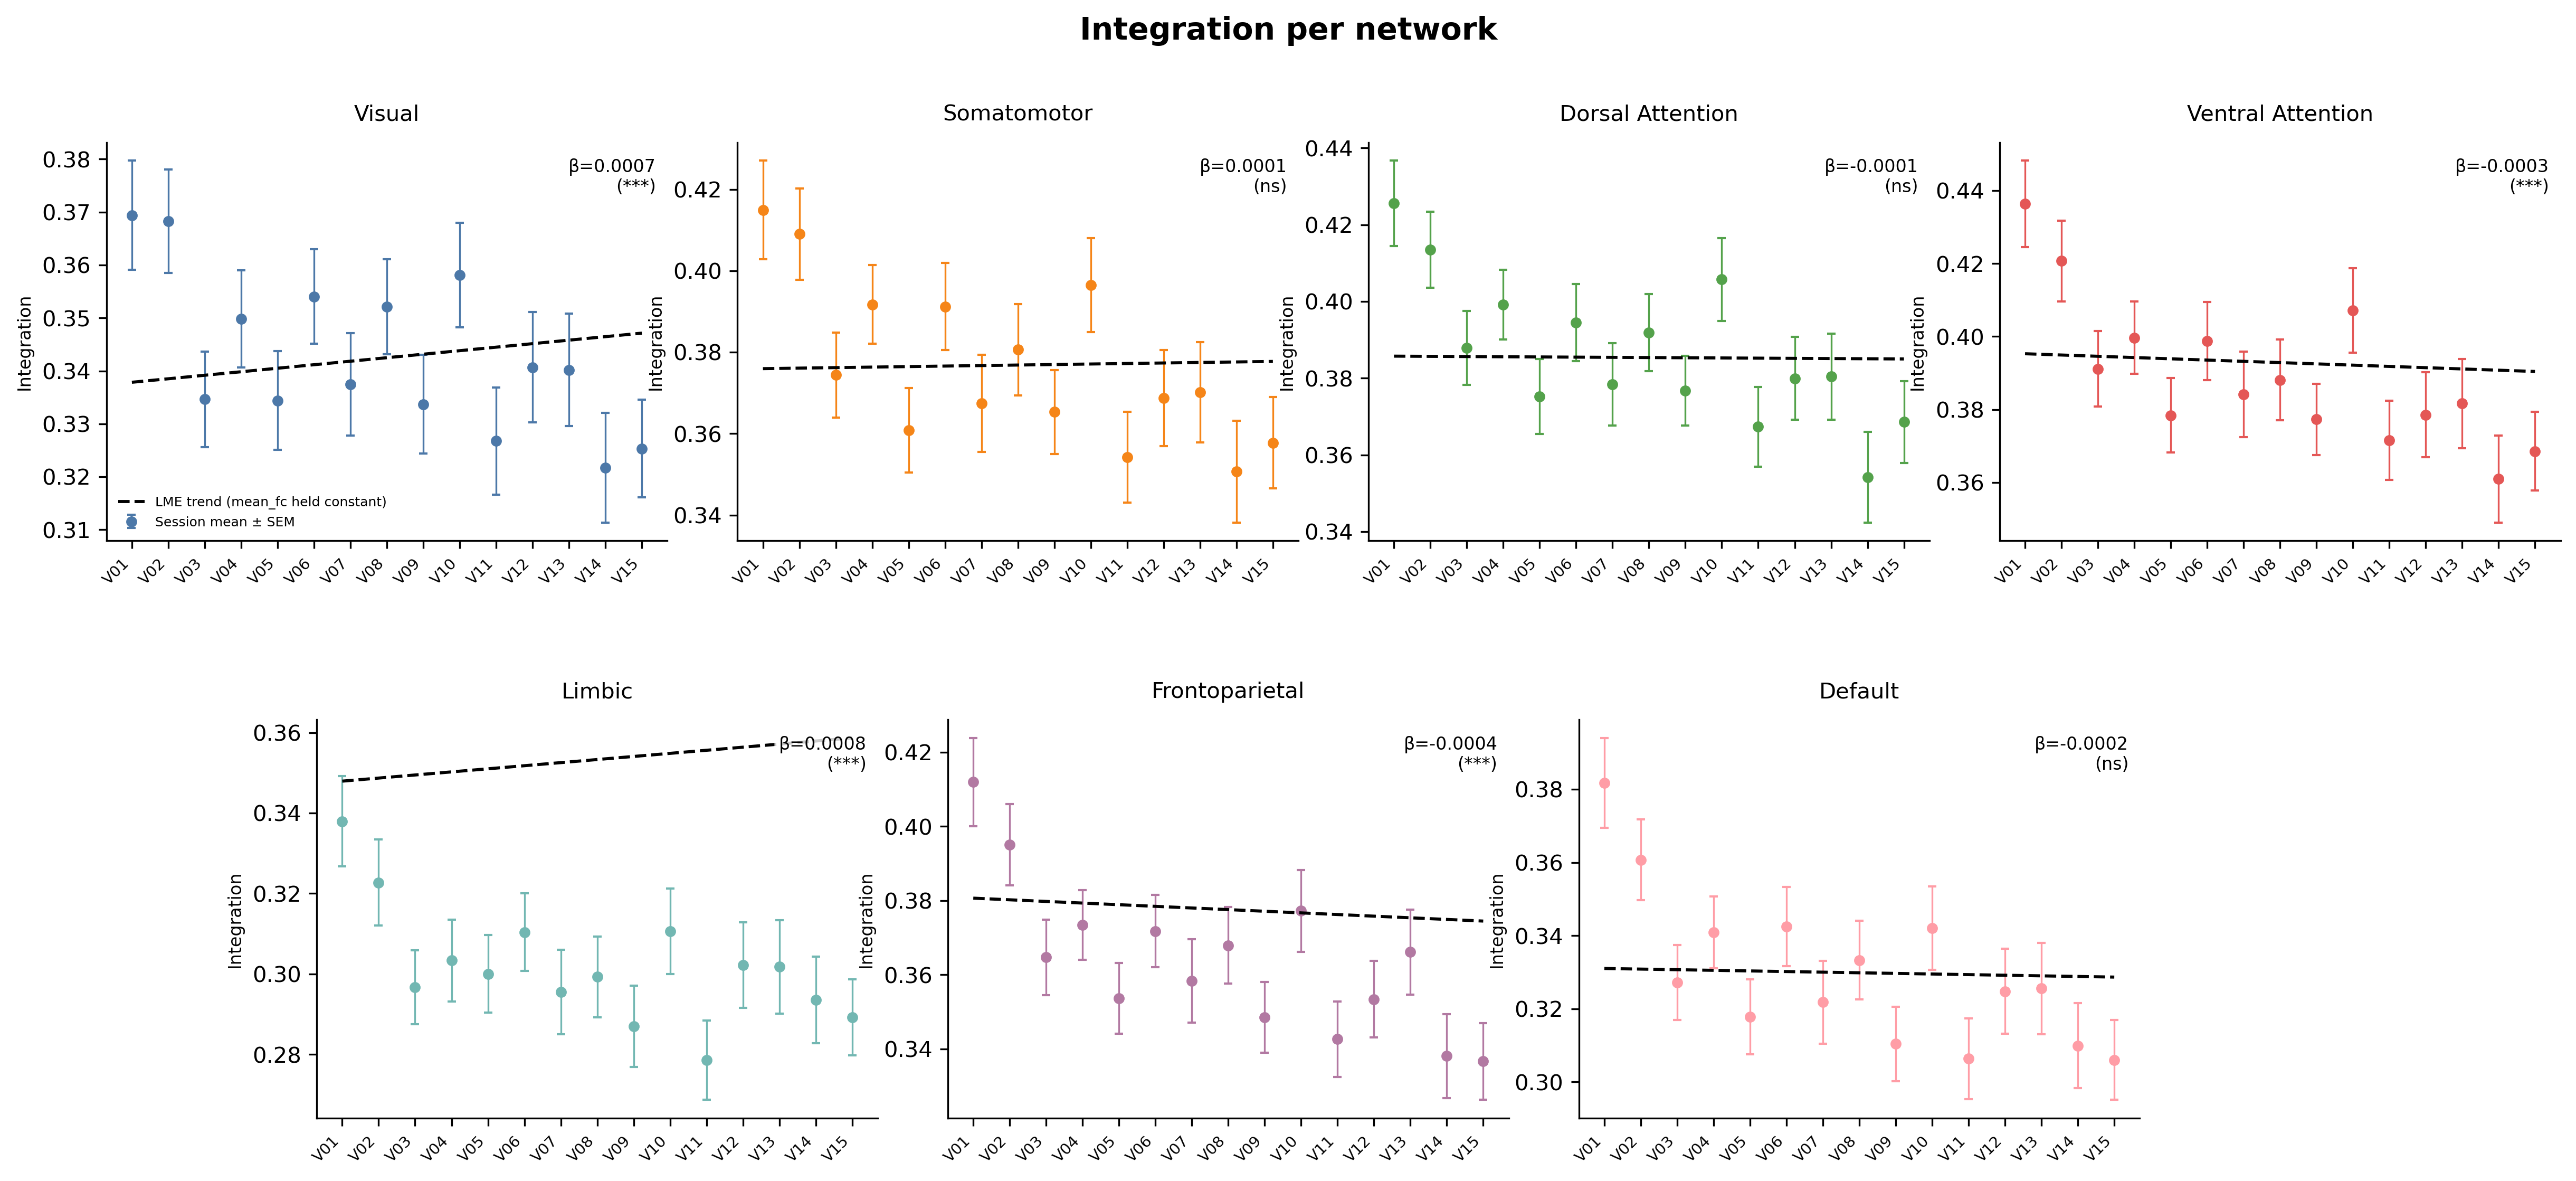

,network,beta_session,p_session
0,1,0.000663,0.000040
1,2,0.000126,0.246817
2,3,-0.000052,0.676647
3,4,-0.000347,0.000563
4,5,0.000767,0.000008
5,6,-0.000441,0.000013
6,7,-0.000168,0.118762


In [15]:
fig, stats_int = plot_trend_per_network(
    df_long=df_long,
    yeo_names=YEO_NAMES,
    metric="integration",
    control_mean_fc=True,
    control_condition=False,
    figsize=(20, 8),
    dpi=300,
)
stats_int

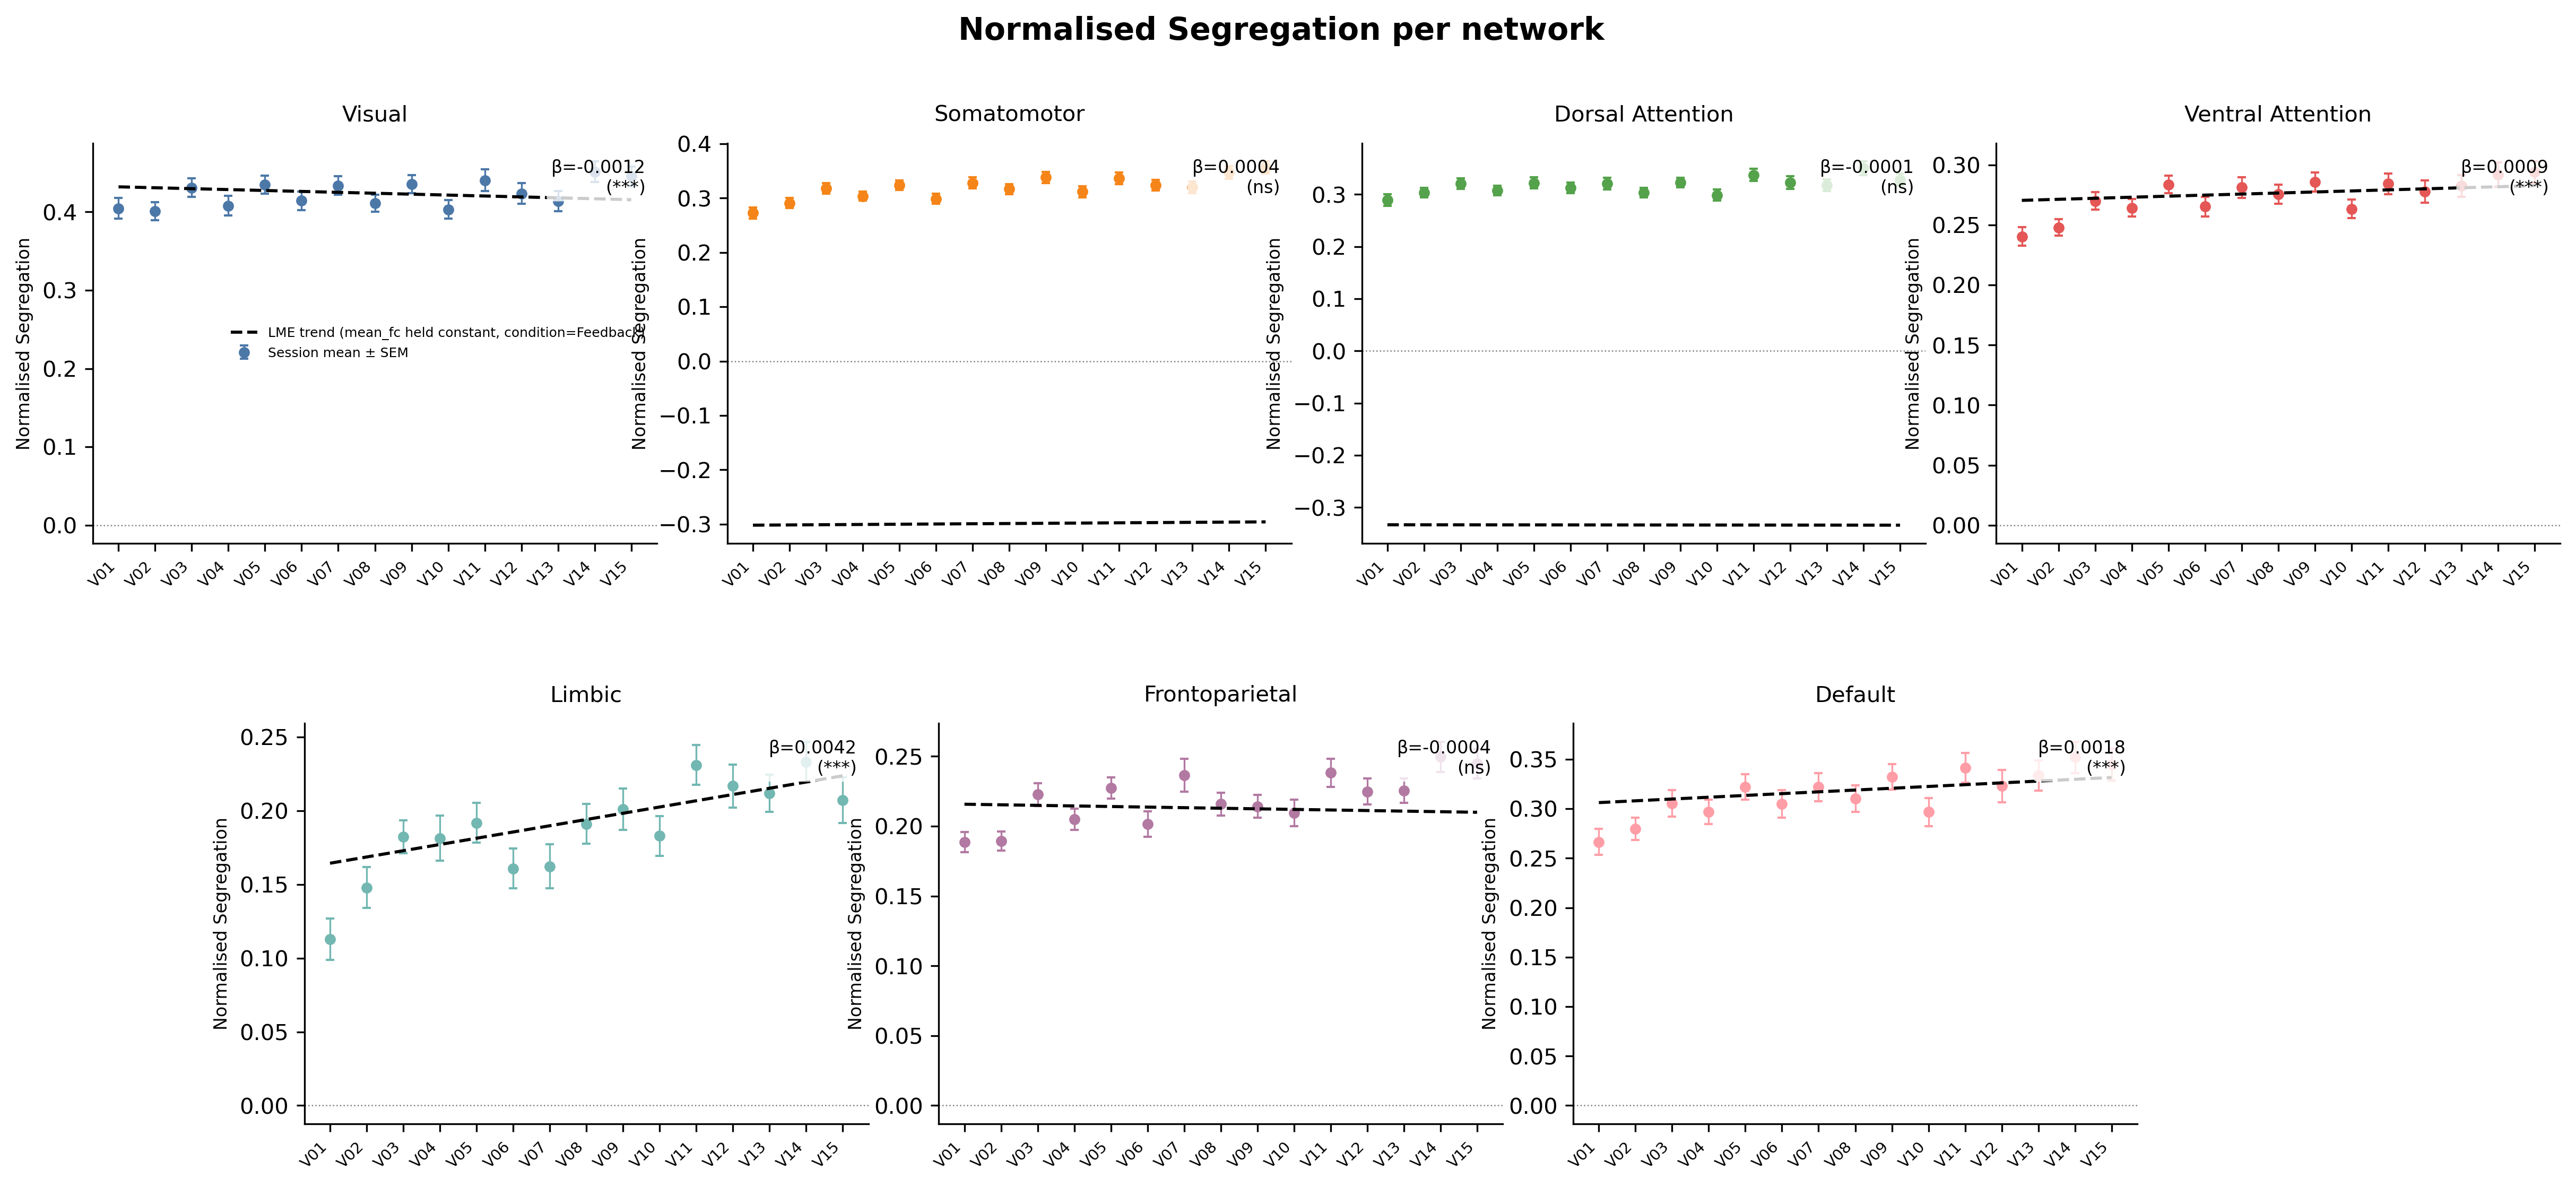

,network,beta_session,p_session,beta_Transfer,p_Transfer,beta_NoFeedback,p_NoFeedback
0,1,-0.001171,3.326456e-04,-0.000418,8.999077e-01,0.010855,0.082436
1,2,0.000434,2.212873e-01,0.022045,1.102614e-09,0.025752,0.000151
2,3,-0.000053,8.561449e-01,-0.015548,2.096809e-07,0.000281,0.960232
3,4,0.000873,5.067306e-04,-0.006691,8.887632e-03,-0.014849,0.002000
4,5,0.004238,6.668727e-10,-0.018744,7.364403e-03,-0.022745,0.083494
5,6,-0.000412,1.869224e-01,0.029485,2.004935e-20,0.027761,0.000003
6,7,0.001813,5.181079e-06,-0.008732,3.122836e-02,-0.017174,0.024131


In [25]:
fig, stats_norm_segregation = plot_trend_per_network(
    df_long=df_long,
    yeo_names=YEO_NAMES,
    metric="normalized_segregation",
    control_mean_fc=True,
    control_condition=True,
    figsize=(20, 8),
    dpi=300,
)
stats_norm_segregation

In [16]:
df_run = df_long.drop_duplicates(subset=["subject", "session", "run"])[
    ["subject", "session_num", "run", "condition", "mean_fc"]
].copy()

lme_mfc = smf.mixedlm(
    "mean_fc ~ session_num + C(condition, Treatment('Feedback'))",
    data=df_run,
    groups=df_run["subject"]
).fit(reml=True, method="lbfgs")

print(lme_mfc.summary())


                           Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             mean_fc  
No. Observations:              1887                Method:                         REML     
No. Groups:                    20                  Scale:                          0.0049   
Min. group size:               88                  Log-Likelihood:                 2268.0636
Max. group size:               106                 Converged:                      Yes      
Mean group size:               94.3                                                         
--------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                          0.377    0.019 20.321 0.000  0.341  0.414
C(con

c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [17]:
formulas = {
    ("segregation", False): "segregation ~ session_num",
    ("segregation", True):  "segregation ~ session_num + mean_fc",
    ("integration", False): "integration ~ session_num",
    ("integration", True):  "integration ~ session_num + mean_fc",
}

rows = []
for net_id, net_name in enumerate(YEO_NAMES, start=1):
    net_df = df_long[df_long["network"] == net_id].copy()
    row = {"Network": net_name}
    for (metric, ctrl), formula in formulas.items():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            lme = smf.mixedlm(formula, data=net_df, groups=net_df["subject"]).fit(
                reml=True, method="lbfgs"
            )
        beta  = lme.params["session_num"]
        p     = lme.pvalues["session_num"]
        label = "mean-corrected" if ctrl else ""
        row[f"{metric[:3]}-{label}-β"] = round(beta, 4)
        row[f"{metric[:3]}-{label}-p"] = stars_from_p(p)
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Network")
summary

,seg--β,seg--p,seg-mean-corrected-β,seg-mean-corrected-p,int--β,int--p,int-mean-corrected-β,int-mean-corrected-p
Network,,,,,,,,
Visual,-0.0019,***,-0.0002,ns,-0.0022,***,0.0007,***
Somatomotor,-0.0018,***,0.0009,**,-0.0031,***,0.0001,ns
Dorsal Attention,-0.0031,***,-0.0008,***,-0.0031,***,-0.0001,ns
Ventral Attention,-0.0031,***,-0.0005,*,-0.0035,***,-0.0003,***
Limbic,0.0001,ns,0.0023,***,-0.0020,***,0.0008,***
Frontoparietal,-0.0029,***,-0.0004,*,-0.0035,***,-0.0004,***
Default,-0.0020,***,0.0004,ns,-0.0034,***,-0.0002,ns


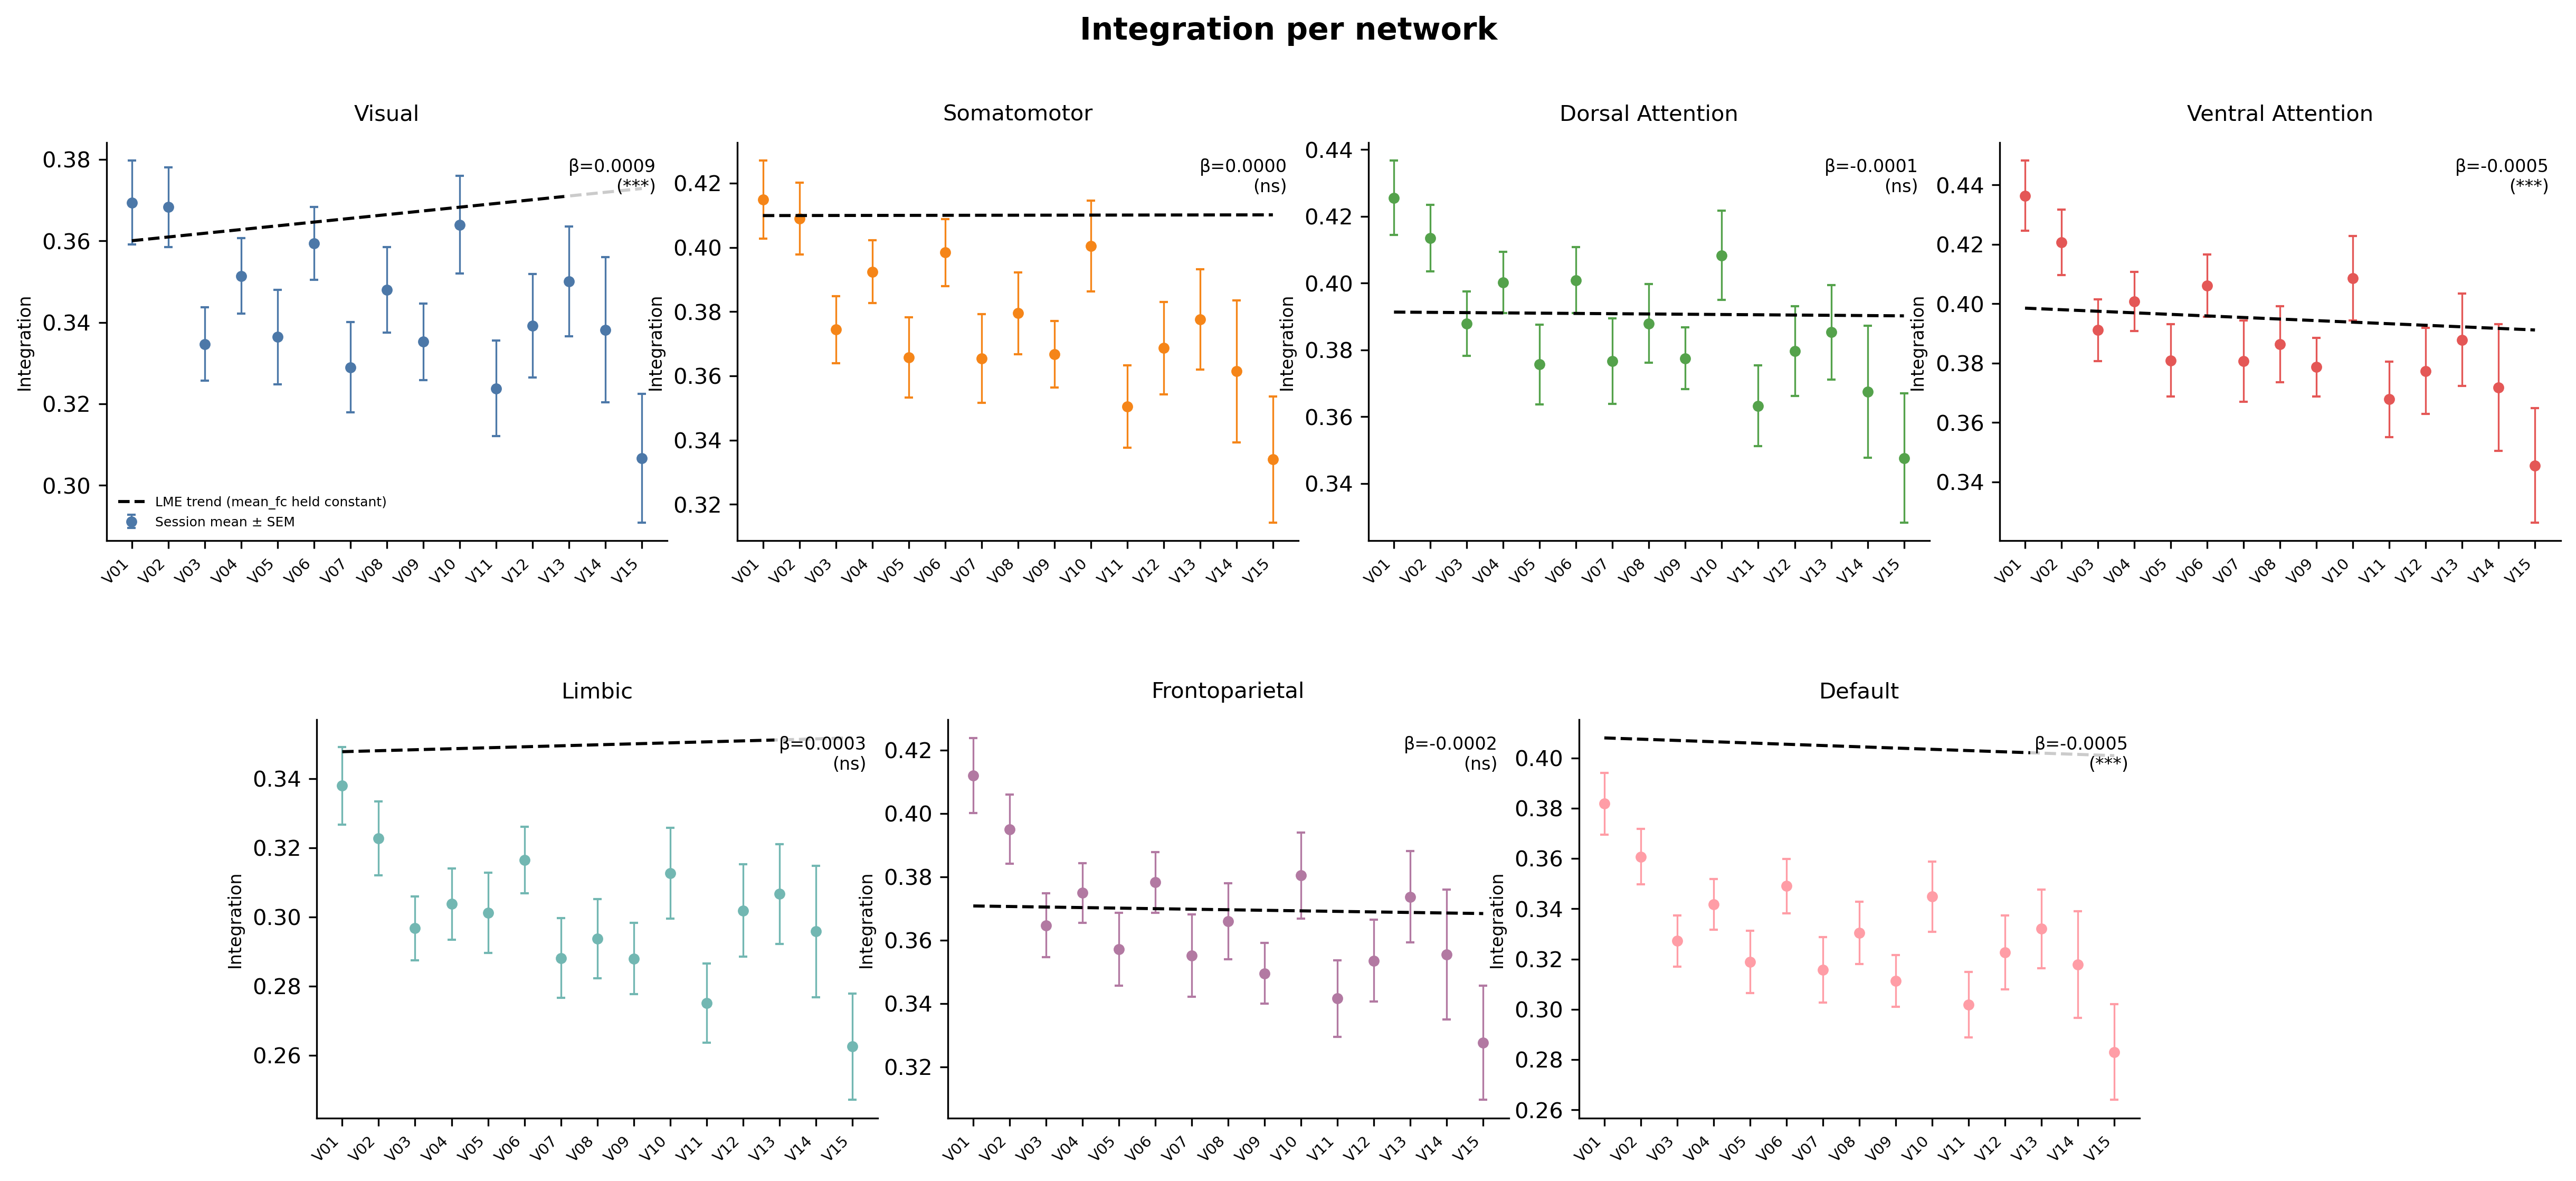

,network,beta_session,p_session
0,1,0.000915,0.000003
1,2,0.000016,0.898502
2,3,-0.000081,0.591030
3,4,-0.000525,0.000015
4,5,0.000285,0.173482
5,6,-0.000171,0.143851
6,7,-0.000504,0.000085


In [26]:
df_long_feedback = df_long[df_long["condition"] == "Feedback"].copy()

fig, stats_int = plot_trend_per_network(
    df_long=df_long_feedback,
    yeo_names=YEO_NAMES,
    metric="integration",
    control_mean_fc=True,
    control_condition=False,
    figsize=(20, 8),
    dpi=300,
)
stats_int